Classification of Requests as Having a Resolution Time > 30 days or < 30 days based on the Neighborhood, Request Type, etc.

Steps:
1. Cut down on neighborhoods with very high average resolution times (outliers)
2. Correlation Matrices (neighborhood & request type vs. is_closed & request_status)
3. Feature Importance
4. Models
    a) Linear Regression - Naive Bayes
    b) Random Forest Classifier
    c) SVM (Support Vector Machine)
5. Validation
    a) Accuracy (optional)
    b) Precision
    c) Recall
    d) Qualitative Measures
6. Interpretation

TA Notes:
- EDA: do a correlation matrix and see corr between features & Y variable
- EDA: find out how to cut down on neighborhoods to focus on where there are very high resolution times
- Modeling: start with basic Naive Bayes - linear regression
- Random forest classifier - has good fine tuning parameters but doesn't generalize well on training so sometimes overlearns on testing data
- SVM (support vector machine): really good but takes a long time to run (especially on our big dataset, so can maybe take a smaller sample to do that)
- Feature importance - which independent features explain the variance/variability on Y variable the most (for ex. start date) - DROP those columns before modeling since they'd be highly correlated
- Validation: test accuracy based on these 3 & pick one at the end
- Look at different parameters & evaluation metrics - focus on either precision or recall (accuracy is not good) - which error is more costly in our case, and decide which model is best for this case on the basis of that metric
- Qualitative measures to look at: ease of deployment, how to make sense of results from model, (for ex. can't make sense of Random Forest but can interpret the others), which best avoids biases and considers ethics, etc.
- In final paper: focus on the project scoping aspect more

Part 2 STEPS:
Hadi
- Calculate accuracy for all models
- Look at different parameters & evaluation metrics - focus on either precision or recall (accuracy is not good) - which error is more costly in our case, and decide which model is best for this case on the basis of that metric
- Qualitative measures to look at: ease of deployment, how to make sense of results from model, (for ex. can't make sense of Random Forest but can interpret the others), which best avoids biases and considers ethics, etc.

Sri
- Feature importance
- SVM run time

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score

In [72]:
csv_path = "clean3.csv"

df = pd.read_csv(csv_path, 
                 parse_dates=['create_date_et', 'closed_date_filled'], 
                 engine='python')

In [74]:
# Inspect its structure
print(df.info())
print(df.head())

# Show how many rows and columns remain after cleaning
print("Shape:", df.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 316673 entries, 0 to 316672
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   _id                            316673 non-null  int64         
 1   group_id                       316673 non-null  int64         
 2   num_requests                   316673 non-null  int64         
 3   status_name                    316673 non-null  object        
 4   status_code                    316673 non-null  int64         
 5   dept                           316673 non-null  object        
 6   request_type_id                316673 non-null  int64         
 7   create_date_et                 316673 non-null  datetime64[ns]
 8   last_action_et                 316673 non-null  object        
 9   closed_date_et                 266448 non-null  object        
 10  origin                         316673 non-null  object        
 11  

In [75]:
# binary target: backlog if >30 days OR still open
df["label"] = (
    (df["resolution_time"] > 30) |
    (df["request_status"].str.lower() == "open")
).astype(int)

In [76]:
# FEATURE ENGINEERING #
df = df.sort_values("create_date_et")

In [77]:
# time since last similar ticket at that location
df["time_since_last"] = (
    df.groupby(["neighborhood", "request_type_name"])["create_date_et"]
      .diff()
      .dt.total_seconds()
      / 86400
).fillna(np.nan)

df["time_since_last"].fillna(df["time_since_last"].median(), inplace=True)

C:\Users\panna\AppData\Local\Temp\ipykernel_28356\563017397.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["time_since_last"].fillna(df["time_since_last"].median(), inplace=True)


In [78]:
# rolling avg closure by request type
df["rolling_avg_closure"] = (
    df.groupby("request_type_name")["resolution_time"]
      .expanding()
      .mean()
      .shift()
      .reset_index(level=0, drop=True)
).fillna(df["resolution_time"].mean())

In [63]:
## TAKING TOO LONG TO RUN ##

# # department workload = # of tickets open at creation time
# df["closure_date"] = df["create_date_et"] + pd.to_timedelta(df["resolution_time"], unit="D")
# df["dept_workload"] = df.apply(
#     lambda row: ((df["create_date_et"] < row["create_date_et"]) &
#                  (df["closure_date"] > row["create_date_et"])).sum(),
#     axis=1
# )

In [79]:
# OUTLIER REMOVAL (NEIGHBORHOODS) #
# remove neighborhoods whose mean resolution_time is an outlier by IQR rule
nbr_means = df.groupby("neighborhood")["resolution_time"].mean()
Q1, Q3 = nbr_means.quantile([0.25, 0.75])
IQR = Q3 - Q1
outlier_nbrs = nbr_means[nbr_means > Q3 + 1.5 * IQR].index
df = df[~df["neighborhood"].isin(outlier_nbrs)].copy()

In [80]:
# CORRELATION MATRICES #
# numeric corr among engineered features + raw resolution_time vs label
num_feats = ["time_since_last", "rolling_avg_closure", "resolution_time"]
corr_num = df[num_feats + ["label"]].corr()
print("\nNumeric correlation matrix:\n", corr_num)

# neighborhood → backlog correlation
loc_corr = pd.get_dummies(df["neighborhood"], prefix="nbr") \
             .join(df["label"]).corr()["label"] \
             .sort_values(ascending=False)
print("\nTop neighborhoods positively correlated with backlog:\n", loc_corr.head(10))


Numeric correlation matrix:
                      time_since_last  rolling_avg_closure  resolution_time  \
time_since_last             1.000000             0.027944        -0.007198   
rolling_avg_closure         0.027944             1.000000         0.526683   
resolution_time            -0.007198             0.526683         1.000000   
label                      -0.014157             0.266677         0.629797   

                        label  
time_since_last     -0.014157  
rolling_avg_closure  0.266677  
resolution_time      0.629797  
label                1.000000  

Top neighborhoods positively correlated with backlog:
 label                    1.000000
nbr_Knoxville            0.029276
nbr_Homewood North       0.016687
nbr_Troy Hill            0.014978
nbr_South Side Slopes    0.012391
nbr_Carrick              0.010326
nbr_Shadyside            0.010095
nbr_East Allegheny       0.009364
nbr_Sheraden             0.009298
nbr_Allentown            0.008839
Name: label, dtype: flo

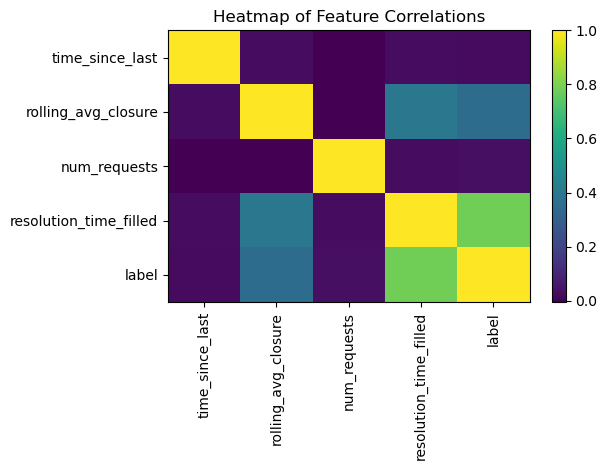

In [ ]:
# Define features for correlation
features = [
    'time_since_last',
    'rolling_avg_closure',
    'num_requests',
    'resolution_time_filled',
    'label'
]

df['label'] = ((df['is_closed'] == 0) | (df['resolution_time_filled'] > 30)).astype(int)

# Compute and plot heatmap
corr_matrix = df[features].corr()
plt.figure()
plt.imshow(corr_matrix, aspect='auto')
plt.colorbar()
plt.xticks(range(len(corr_matrix)), corr_matrix.columns, rotation=90)
plt.yticks(range(len(corr_matrix)), corr_matrix.index)
plt.title('Heatmap of Feature Correlations')
plt.tight_layout()
plt.show()

In [ ]:
# FEATURE DEFINITION #
core_cat = ['neighborhood', 'request_type_name']
engineered_num = ['time_since_last', 'rolling_avg_closure']
context_cat = ['num_requests', 'num_requests_capped', 'dept', 'origin',
               'council_district', 'public_access_level']
features = core_cat + engineered_num

X = df[features]
y = df['label']

# TIME-BASED DATA SPLIT # 
# 80% train, 20% test
split_idx = int(0.8 * len(df))
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

In [ ]:
# PREPROCESSING PIPELINE #
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), ['time_since_last', 'rolling_avg_closure']),
    ('cat', OneHotEncoder(handle_unknown='ignore'), ['neighborhood', 'request_type_name'])
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

In [ ]:
# LOGISTIC REGRESSION #

from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report

pipe_lr = Pipeline([('pre', preprocessor), ('model', LogisticRegression(max_iter=1000))])

grid_lr = GridSearchCV(pipe_lr, {'model__C': [0.1, 1, 10]}, cv=cv, scoring='precision', n_jobs=-1)

grid_lr.fit(X_train, y_train)

y_pred = grid_lr.predict(X_test)

print("Logistic Regression Best Params:", grid_lr.best_params_)
print(classification_report(y_test, y_pred, target_names=['<=30 days', '>30 days or open']))

Logistic Regression Best Params: {'model__C': 0.1}
                  precision    recall  f1-score   support

       <=30 days       0.74      0.94      0.83     40808
>30 days or open       0.73      0.34      0.47     20220

        accuracy                           0.74     61028
       macro avg       0.73      0.64      0.65     61028
    weighted avg       0.74      0.74      0.71     61028



In [ ]:
# NAIVE BAYES #

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import classification_report

pipe_nb = Pipeline([
    ('pre', preprocessor),
    ('to_dense', FunctionTransformer(lambda X: X.toarray(), accept_sparse=True)),
    ('model', GaussianNB())
])

pipe_nb.fit(X_train, y_train)
y_pred = pipe_nb.predict(X_test)

print("Naïve Bayes Classification Report:")
print(classification_report(
    y_test, 
    y_pred, 
    target_names=['<=30 days','>30 days or open']
))

Naïve Bayes Classification Report:
                  precision    recall  f1-score   support

       <=30 days       0.76      0.87      0.81     40808
>30 days or open       0.62      0.44      0.51     20220

        accuracy                           0.73     61028
       macro avg       0.69      0.65      0.66     61028
    weighted avg       0.71      0.73      0.71     61028



In [ ]:
# RANDOM FOREST CLASSIFIER #

from sklearn.ensemble import RandomForestClassifier

pipe_rf = Pipeline([('pre', preprocessor), ('model', RandomForestClassifier(random_state=42))])
grid_rf = GridSearchCV(pipe_rf, {'model__n_estimators': [100, 200], 'model__max_depth': [5, 10]},
                       cv=cv, scoring='precision', n_jobs=-1)
grid_rf.fit(X_train, y_train)
y_pred = grid_rf.predict(X_test)
print("Random Forest Best Params:", grid_rf.best_params_)
print(classification_report(y_test, y_pred, target_names=['<=30 days', '>30 days or open']))



Random Forest Best Params: {'model__max_depth': 5, 'model__n_estimators': 200}
                  precision    recall  f1-score   support

       <=30 days       0.68      1.00      0.81     40808
>30 days or open       0.97      0.07      0.13     20220

        accuracy                           0.69     61028
       macro avg       0.83      0.53      0.47     61028
    weighted avg       0.78      0.69      0.59     61028



In [ ]:
# SVM - Support Vector Machine # - has taken over 98 minutes - cell below is a different implementation

from sklearn.svm import SVC

# pipe_svm = Pipeline([('pre', preprocessor), ('model', SVC())])
# grid_svm = GridSearchCV(pipe_svm, {'model__C': [0.1, 1, 10]}, cv=cv, scoring='precision', n_jobs=-1)
# grid_svm.fit(X_train, y_train)
# y_pred = grid_svm.predict(X_test)
# print("SVM Best Params:", grid_svm.best_params_)
# print(classification_report(y_test, y_pred, target_names=['<=30 days', '>30 days or open']))


In [70]:
from sklearn.svm import LinearSVC
pipe_svm = Pipeline([
    ('pre', preprocessor),
    ('model', LinearSVC(max_iter=10_000, C=1.0))
])
pipe_svm.fit(X_train, y_train)

X_sub, y_sub = X_train.sample(50_000, random_state=42), y_train.sample(50_000, random_state=42)
grid_svm = GridSearchCV(pipe_svm, {'model__C':[0.1,1,10]}, cv=3, n_jobs=-1)
grid_svm.fit(X_sub, y_sub)

from sklearn.linear_model import SGDClassifier
pipe_sgd = Pipeline([
    ('pre', preprocessor),
    ('model', SGDClassifier(loss='hinge', max_iter=5_000))
])
pipe_sgd.fit(X_train, y_train)


Pipeline(steps=[('pre',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['time_since_last',
                                                   'rolling_avg_closure']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['neighborhood',
                                                   'request_type_name'])])),
                ('model', SGDClassifier(max_iter=5000))])

In [85]:
# TESTING!! #

# # MODEL BUILDING & VALIDATION #
# models = {
#     "LogisticRegression": LogisticRegression(max_iter=1000),
#     "NaiveBayes":         GaussianNB(),
#     "RandomForest":       RandomForestClassifier(random_state=42),
#     "SVM":                SVC()
# }
# param_grids = {
#     "LogisticRegression": {"model__C": [0.1, 1, 10]},
#     "NaiveBayes":         {},
#     "RandomForest":       {"model__n_estimators": [100,200], "model__max_depth": [5,10]},
#     "SVM":                {"model__C": [0.1, 1, 10]}
# }

# skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
# results = []

# for name, clf in models.items():
#     pipe = Pipeline([("pre", preprocessor), ("model", clf)])
#     grid = GridSearchCV(pipe, param_grids[name], cv=skf,
#                         scoring="precision", n_jobs=-1)
#     grid.fit(X_train, y_train)
#     y_pred = grid.predict(X_test)
#     results.append({
#         "Model":     name,
#         "Accuracy":  accuracy_score(y_test, y_pred),
#         "Precision": precision_score(y_test, y_pred),
#         "Recall":    recall_score(y_test, y_pred),
#         "Best_Params": grid.best_params_
#     })

# results_df = pd.DataFrame(results)
# print("\nModel comparison:\n", results_df)